In [1]:
import os
import numpy as np
from skimage.feature import hog, local_binary_pattern
from skimage.color import rgb2gray
from skimage.transform import resize
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [5]:
DATASET_PATH = "../dataset"
classes = ["minor", "moderate", "severe"]

images = []
labels = []

for label_idx, cls in enumerate(classes):
    folder = os.path.join(DATASET_PATH, cls)
    for img_name in os.listdir(folder):
        img = Image.open(os.path.join(folder, img_name)).convert("RGB")
        img = img.resize((128, 128))
        img = np.array(img)
        images.append(img)
        labels.append(label_idx)

images = np.array(images)
labels = np.array(labels)
len(images), len(labels)

(1383, 1383)

In [6]:
hog_features = []

for img in images:
    gray = rgb2gray(img)
    gray = resize(gray, (128, 128))
    feat = hog(gray, pixels_per_cell=(16, 16), cells_per_block=(2, 2))
    hog_features.append(feat)

hog_features = np.array(hog_features)
hog_features.shape

(1383, 1764)

In [7]:
lbp_features = []

for img in images:
    gray = rgb2gray(img)
    gray = resize(gray, (128, 128))
    lbp = local_binary_pattern(gray, P=8, R=1)
    lbp_features.append(lbp.flatten())

lbp_features = np.array(lbp_features)
lbp_features.shape

c:\Users\Korisnik\AppData\Local\Programs\Python\Python310\lib\site-packages\skimage\feature\texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


(1383, 16384)

In [8]:
pca = PCA(n_components=50)
hog_pca = pca.fit_transform(hog_features)
hog_pca.shape

(1383, 50)

In [9]:
pca_lbp = PCA(n_components=50)
lbp_pca = pca_lbp.fit_transform(lbp_features)
lbp_pca.shape

(1383, 50)

In [10]:
np.save("../models/hog_features.npy", hog_features)
np.save("../models/lbp_features.npy", lbp_features)
np.save("../models/hog_pca.npy", hog_pca)
np.save("../models/lbp_pca.npy", lbp_pca)
np.save("../models/labels.npy", labels)

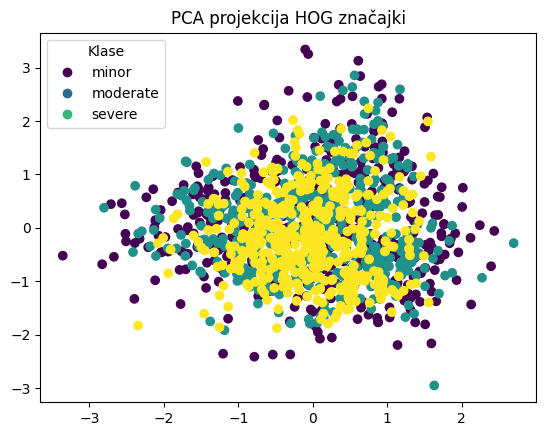

In [ ]:
plt.scatter(hog_pca[:, 0], hog_pca[:, 1], c=labels, cmap="viridis")
plt.title("PCA projekcija HOG značajki")
plt.xlabel("PC1")
plt.ylabel("PC2")

handles = []

for i, cls in enumerate(classes):
    handles.append(
        plt.Line2D([], [], marker="o", color=plt.cm.viridis(i / len(classes)), linestyle="", label=cls)
    )

plt.legend(handles=handles, title="Klase")
plt.show()